## Introduction

This project was created by **Vaishnavi Modanwal**.

The purpose of this project is to study and understand the Gym Members Exercise Tracking Dataset.

We used Exploratory Data Analysis (EDA) to explore the data.

EDA helps us to:
- Understand the dataset
- Find patterns and trends
- Detect unusual values
- See relationships between different features

In this project, we used different graphs like histograms, bar charts, pie charts, line charts, and heatmaps to visualize the data.

This analysis helps us better understand gym members’ health, workout habits, calories burned, BMI, and fitness-related information.

In [29]:
# import libraray 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pywaffle import Waffle

# Load dataset
df = pd.read_csv(r"C:\Users\arvind kumar\Downloads\gym_members_exercise_tracking_synthetic_data.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

numeric_cols = df.select_dtypes(include=['number']).columns


# Style
sns.set(style="whitegrid")


# Basic Info

print(df.head())
print(df.info())


plt.show()

First 5 rows:
    Age  Gender  Weight (kg)  Height (m) Max_BPM  Avg_BPM  Resting_BPM  \
0  34.0  Female         86.7        1.86     174    152.0         74.0   
1  26.0  Female         84.7        1.83     166    156.0         73.0   
2  22.0    Male         64.8        1.85     187    166.0         64.0   
3  54.0  Female         75.3        1.82     187    169.0         58.0   
4  34.0  Female         52.8        1.74     177    169.0         66.0   

   Session_Duration (hours)  Calories_Burned Workout_Type  Fat_Percentage  \
0                      1.12            712.0     Strength            12.8   
1                      1.00            833.0     Strength            27.9   
2                      1.24           1678.0       Cardio            28.7   
3                      1.45            628.0       Cardio            31.8   
4                      1.60           1286.0     Strength            26.4   

   Water_Intake (liters)  Workout_Frequency (days/week)  Experience_Level  \
0

# DATA HANDLING 

In [30]:
# Remove Duplicates

df = df.drop_duplicates()

#  Handle Missing Values

print("\nMissing Values Before:")
print(df.isnull().sum())

# Fill numeric columns with median

numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Fill categorical columns with mode

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values After:")
print(df.isnull().sum())

# 3️⃣ Fix Data Types (if needed)

print("\nData Types:")
print(df.dtypes)

df



Missing Values Before:
Age                              10
Gender                           71
Weight (kg)                      22
Height (m)                       26
Max_BPM                          21
Avg_BPM                          30
Resting_BPM                      19
Session_Duration (hours)         23
Calories_Burned                  23
Workout_Type                     61
Fat_Percentage                   16
Water_Intake (liters)            24
Workout_Frequency (days/week)    58
Experience_Level                 57
BMI                              30
dtype: int64



Missing Values After:
Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

Data Types:
Age                              float64
Gender                            object
Weight (kg)                      float64
Height (m)                       float64
Max_BPM                           object
Avg_BPM                          float64
Resting_BPM                      float64
Session_Duration (hours)         float64
Calories_Burned                  float64
Workout_Type                      object
Fat_Percentage  

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,34.0,Female,86.7,1.86,174,152.0,74.0,1.12,712.0,Strength,12.8,2.4,5.0,2.0,14.31
1,26.0,Female,84.7,1.83,166,156.0,73.0,1.00,833.0,Strength,27.9,2.8,5.0,2.0,33.49
2,22.0,Male,64.8,1.85,187,166.0,64.0,1.24,1678.0,Cardio,28.7,1.9,3.0,2.0,12.73
3,54.0,Female,75.3,1.82,187,169.0,58.0,1.45,628.0,Cardio,31.8,2.4,4.0,1.0,20.37
4,34.0,Female,52.8,1.74,177,169.0,66.0,1.60,1286.0,Strength,26.4,3.2,4.0,2.0,20.83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,54.0,Male,88.5,2.00,173,134.0,58.0,1.11,1388.0,HIIT,27.7,3.7,3.0,2.0,36.73
1796,52.0,Male,84.3,1.69,164,169.0,54.0,0.77,1367.0,HIIT,32.6,2.9,3.0,2.0,15.11
1797,47.0,Male,70.1,1.84,188,129.0,67.0,1.20,1261.0,Strength,28.4,2.5,3.0,2.0,17.99
1798,35.0,Male,49.3,1.71,180,152.0,73.0,1.04,956.0,Cardio,32.9,1.7,4.0,3.0,12.65


# Histplot

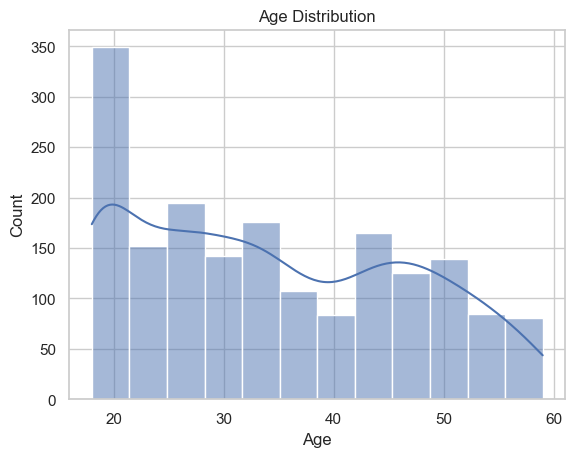

In [31]:
# 1️⃣ Histogram (Seaborn)

plt.figure()
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

# Heat map

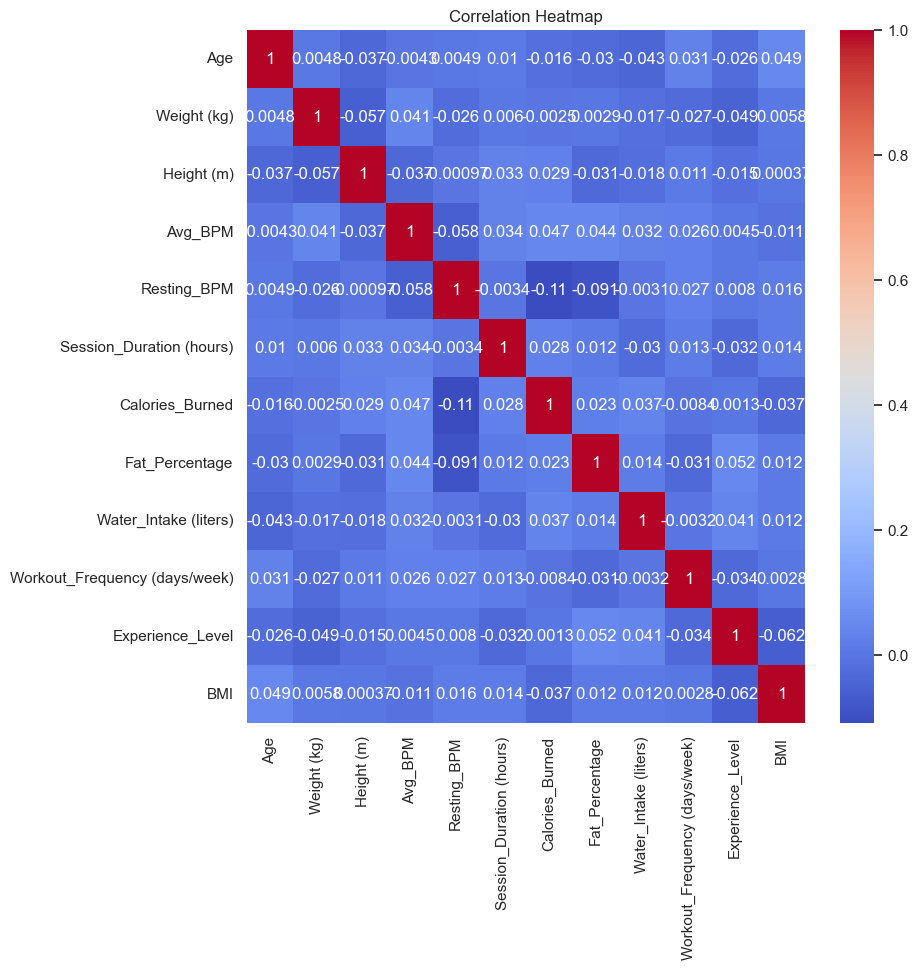

In [32]:
# 2️⃣ Heatmap (Correlation)

plt.figure(figsize=(9, 9))
numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


# Pie chart

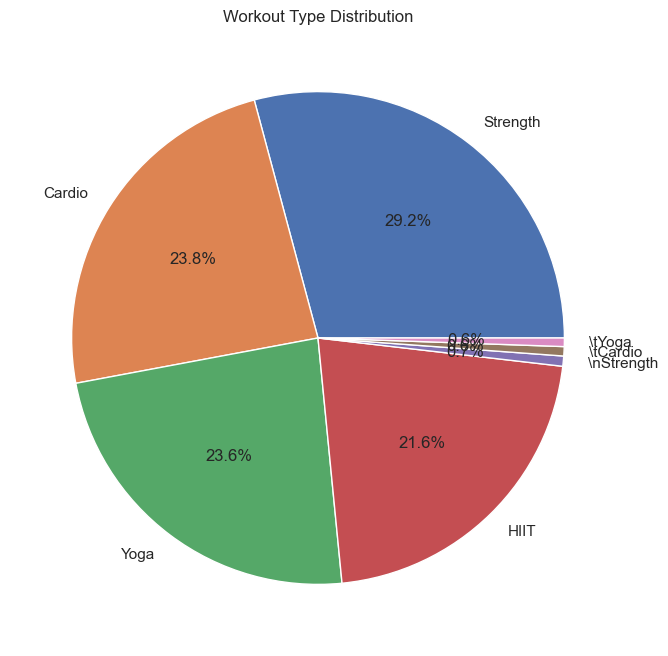

In [33]:
# 3️⃣ Pie Chart (Workout Type)

plt.figure(figsize=(8,8))
df['Workout_Type'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Workout Type Distribution")
plt.ylabel("")
plt.show()

# Line Chart 

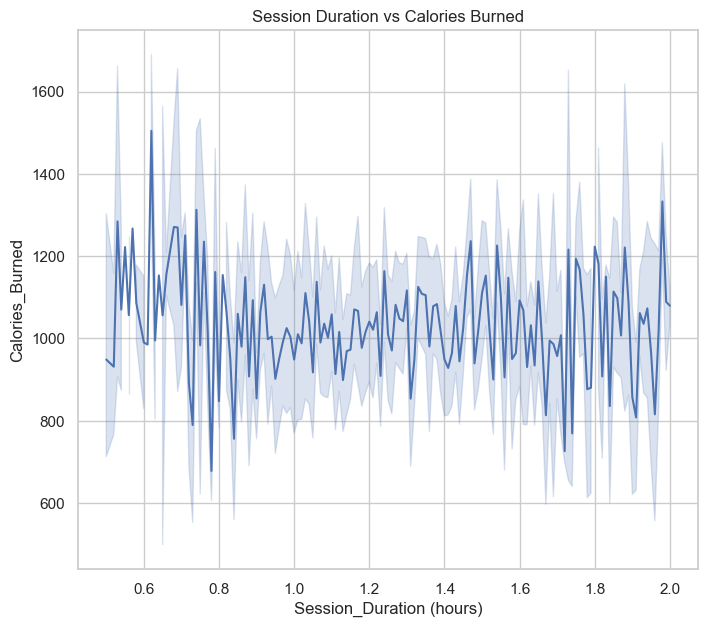

In [34]:
# 4️⃣ Line Chart (Calories Burned Trend)

plt.figure(figsize=(8,7))
df_sorted = df.sort_values(by='Session_Duration (hours)')
sns.lineplot(x='Session_Duration (hours)', y='Calories_Burned', data=df_sorted)
plt.title("Session Duration vs Calories Burned")
plt.show()

# Bar Chart 

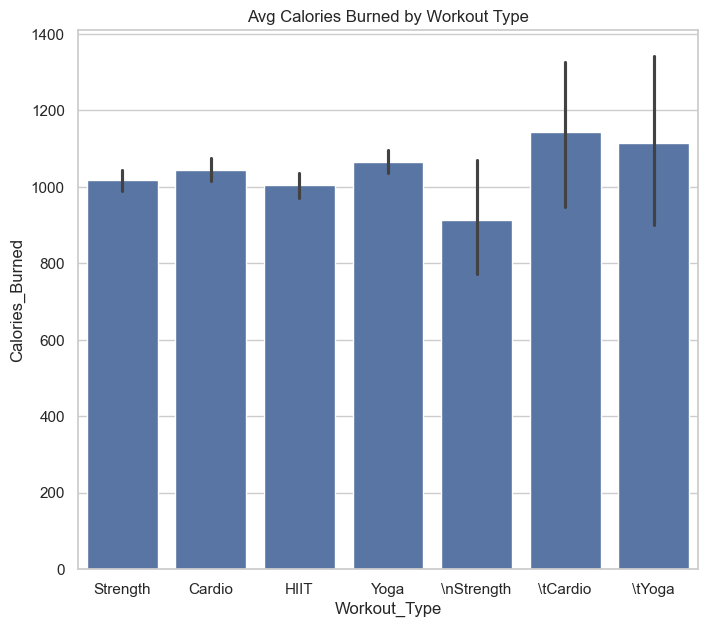

In [35]:
# 5️⃣ Bar Chart (Average Calories by Workout Type)

plt.figure(figsize=(8,7))
sns.barplot(x='Workout_Type', y='Calories_Burned', data=df)
plt.title("Avg Calories Burned by Workout Type")
plt.show()

# Waffle Chart

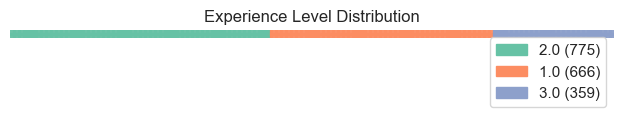

In [36]:
# 6️⃣ Waffle Chart (Experience Level)

experience_counts = df['Experience_Level'].value_counts()

fig = plt.figure(
    FigureClass=Waffle,
    rows=5,
    values=experience_counts,
    title={'label': 'Experience Level Distribution', 'loc': 'center'},
    labels=[f"{k} ({v})" for k, v in experience_counts.items()]
)

##  Conclusion

In this project, we performed Exploratory Data Analysis (EDA) on the Gym Members Exercise Tracking Dataset.

By using different graphs and visualizations, we understood the patterns and relationships in the data.

Key observations from the analysis:

- The dataset includes gym members from different age groups.
- BMI values show that most members are in a normal range, but some outliers exist.
- Members who exercise longer tend to burn more calories.
- Different workout types (Cardio, Strength, etc.) are chosen by members.
- Heart rate values vary based on workout intensity.
- The correlation heatmap helped identify relationships between features like:
  - Session Duration & Calories Burned
  - BMI & Fat Percentage
  - Workout Frequency & Calories Burned

Overall, EDA helped us better understand the dataset, detect trends, and gain useful insights through visualizations.

This project shows how data analysis and graphs can help interpret health and fitness data easily.